# Baseline Model
1. Train a Linear Regression as the first model. 
2. Evaluate using R² on the test set. 
3. Record baseline results. 

### 1. Linear Regression Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')

Y_train = np.load('Y_train.npy')
Y_val = np.load('Y_val.npy')
Y_test = np.load('Y_test.npy')

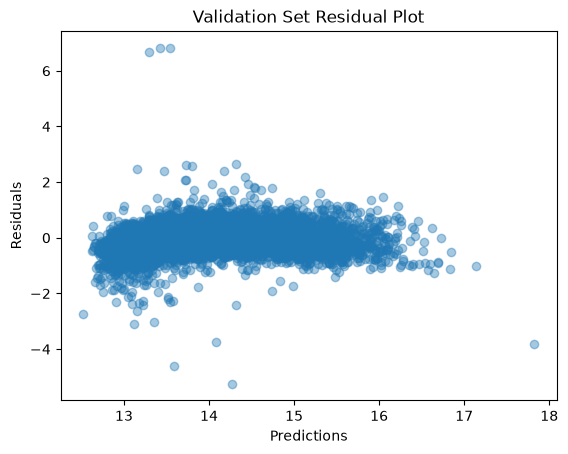

In [2]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, np.log1p(Y_train))

predictions = lr.predict(X_val)
residuals = np.log1p(Y_val) - predictions

plt.scatter(predictions, residuals, alpha=0.4)
plt.title('Validation Set Residual Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals');

In [23]:
X_val[residuals > 4]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
16214,34.490545,-117.257502,4.419449e+05,4.352218e+05,4.421392e+05,1.531073e+06,1910.0,4.0,2.0,2000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19525,33.022839,-116.804242,3.207816e+06,3.207816e+06,3.207816e+06,4.161414e+06,2114.0,3.0,2.0,1984.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23189,33.675959,-117.290553,6.038964e+05,6.430900e+05,6.531664e+05,6.606513e+05,2065.0,4.0,3.0,1997.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
pd.DataFrame(Y_val).sort_values(by=0, ascending=False)

,0
19525,6.990000e+08
23189,6.150000e+08
16214,4.720000e+08
26098,4.000000e+07
8585,3.500000e+07
...,...
22099,2.227500e+04
26421,1.800000e+04
17795,8.300000e+03
22885,8.000000e+03


Our model is underestimating the three highest-value properties.

### 2. R² Evaluation

In [8]:
print('Training score: ', lr.score(X_train, np.log1p(Y_train)))
print('Validation score: ', lr.score(X_val, np.log1p(Y_val)))
print('Test score: ', lr.score(X_test, np.log1p(Y_test)))

Training score:  0.8102311912023247
Validation score:  0.7874895057688374
Test score:  0.7960094397843


##### K-Fold Cross Validation

Combine training and validation datasets to remove outliers.

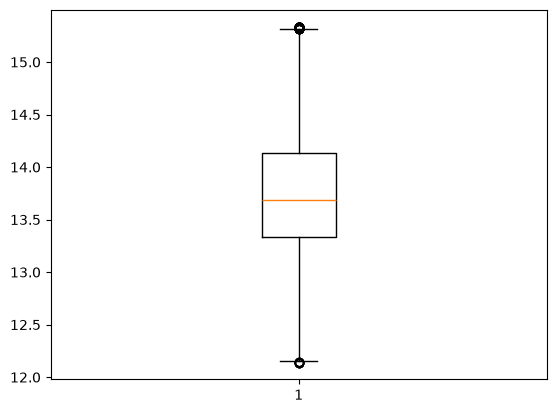

In [ ]:
X_train_val = pd.concat([X_train, X_val], axis=0)
Y_train_val = pd.concat([pd.DataFrame(Y_train), pd.DataFrame(Y_val)], axis=0).rename(columns={0: 'ClosePrice'})
train_val_df = pd.concat([X_train_val, Y_train_val], axis=1)

Q1 = np.log1p(train_val_df['ClosePrice']).quantile(0.25)
Q3 = np.log1p(train_val_df['ClosePrice']).quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (np.log1p(train_val_df['ClosePrice']) <= lower_bound) | (np.log1p(train_val_df['ClosePrice']) >= upper_bound)

train_val_df = train_val_df[~is_outlier]
plt.boxplot(np.log1p(train_val_df['ClosePrice']));

X_train_val = train_val_df.drop(['ClosePrice'], axis=1)
Y_train_val = train_val_df[['ClosePrice']]

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

lr_kfold = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr_kfold, X_train_val, Y_train_val, cv=kf)

for i in range(len(scores)):
    print(f'Fold {i+1} Score: {scores[i]}')

Fold 0 Score: 0.7608442821976324
Fold 1 Score: 0.7812787908476905
Fold 2 Score: 0.7880458887989195
Fold 3 Score: 0.7883329611731466
Fold 4 Score: 0.786134379440389


### 3. Baseline Results